# CA Affordable Housing Tax Credit Intelligence Platform
## Notebook 04 — Modeling

**Input:** Fitted pipeline + train/test splits from `03_feature_engineering.ipynb`

**Models:**
1. Ridge Regression (interpretable baseline)
2. Random Forest
3. XGBoost
4. Stacking Ensemble (Ridge + RF + XGBoost → Ridge meta)
5. LightGBM Quantile (p10/p50/p90) with crossing fix
6. KNN (market comparables) + KMeans (project archetypes)

**All regression models** train on `log1p(annual_federal_award)` and back-transform via `expm1()`.

**Output:** `models/*.pkl` — all saved models for Streamlit app

In [ ]:
import warnings
import os
import gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)

# Memory-safe: n_jobs=1 avoids subprocess data duplication that causes OOM on laptops.
# n_jobs=-1 spawns one process per CPU core, each copying the full dataset into memory.
N_JOBS = 1

MODEL_DIR = '../models'
print('Setup complete')

Setup complete


## 1. Load Data from Notebook 03

In [5]:
# Load pre-transformed arrays
X_train = np.load(os.path.join(MODEL_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(MODEL_DIR, 'X_test.npy'))
y_train_raw = np.load(os.path.join(MODEL_DIR, 'y_train.npy'))
y_test_raw = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))

# Load raw DataFrames for metadata / comparables
df_train = pd.read_parquet(os.path.join(MODEL_DIR, 'train_data.parquet'))
df_test = pd.read_parquet(os.path.join(MODEL_DIR, 'test_data.parquet'))

# Load feature config
feature_config = joblib.load(os.path.join(MODEL_DIR, 'feature_config.pkl'))
feature_names = feature_config['feature_names_out']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {len(y_train_raw):,}, y_test: {len(y_test_raw):,}')

X_train: (3536, 24), X_test: (851, 24)
y_train: 3,536, y_test: 851


## 2. Log-Transform Target

All regression models train on `log1p(annual_federal_award)` to reduce right skew (raw skewness ~2.80 → ~-0.23).

In [6]:
y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)

from scipy.stats import skew
print(f'Raw train skewness:  {skew(y_train_raw):.2f}')
print(f'Log train skewness:  {skew(y_train):.2f}')
print(f'Raw test skewness:   {skew(y_test_raw):.2f}')
print(f'Log test skewness:   {skew(y_test):.2f}')

Raw train skewness:  4.31
Log train skewness:  -0.28
Raw test skewness:   1.38
Log test skewness:   -0.39


## 3. Helpers

In [7]:
def compute_metrics(name, y_true_raw, y_pred_raw):
    """Compute metrics on the original dollar scale."""
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    r2 = r2_score(y_true_raw, y_pred_raw)
    # MAPE — avoid division by zero
    mask = y_true_raw > 0
    mape = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask])) * 100
    # % within 10% of actual
    pct_within_10 = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask]) < 0.10) * 100
    
    return {
        'Model': name,
        'RMSE ($)': rmse,
        'MAE ($)': mae,
        'R2': r2,
        'MAPE (%)': mape,
        'Within 10%': pct_within_10,
    }


def fit_predict_log(name, model, X_tr, y_tr_log, X_te, y_te_raw):
    """Fit on log target, predict, back-transform, compute metrics."""
    model.fit(X_tr, y_tr_log)
    y_pred_log = model.predict(X_te)
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.maximum(y_pred_raw, 0)  # floor at 0
    return compute_metrics(name, y_te_raw, y_pred_raw), y_pred_raw


results = []  # collect all model metrics

## 4. Cross-Validation Setup

Walk-forward `TimeSeriesSplit(n_splits=4)` within the 2000-2021 training window. The 2022-2025 holdout is never touched during tuning.

In [8]:
tscv = TimeSeriesSplit(n_splits=4)

# Verify folds
pis_years_train = df_train['pis_year'].values
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    tr_years = pis_years_train[tr_idx]
    val_years = pis_years_train[val_idx]
    print(f'Fold {i+1}: train {tr_years.min()}-{tr_years.max()} ({len(tr_idx):,}) -> '
          f'val {val_years.min()}-{val_years.max()} ({len(val_idx):,})')

Fold 1: train 2000-2010 (708) -> val 2001-2012 (707)
Fold 2: train 2000-2012 (1,415) -> val 2006-2016 (707)
Fold 3: train 2000-2016 (2,122) -> val 2013-2020 (707)
Fold 4: train 2000-2020 (2,829) -> val 2016-2021 (707)


## 5. Model 1 — Ridge Regression (Baseline)

In [9]:
# Cross-validate alpha
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print(f'Best alpha: {ridge_cv.alpha_}')

# Final Ridge with best alpha
ridge = Ridge(alpha=ridge_cv.alpha_)
ridge_metrics, ridge_preds = fit_predict_log('Ridge', ridge, X_train, y_train, X_test, y_test_raw)
results.append(ridge_metrics)

print(f'Ridge R2: {ridge_metrics["R2"]:.4f}')
print(f'Ridge MAPE: {ridge_metrics["MAPE (%)"]:.1f}%')

Best alpha: 100.0
Ridge R2: -0.0605
Ridge MAPE: 43.8%


## 6. Model 2 — Random Forest

In [10]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=N_JOBS,
)
rf_search.fit(X_train, y_train)
print(f'Best RF params: {rf_search.best_params_}')

rf = rf_search.best_estimator_
rf_metrics, rf_preds = fit_predict_log('Random Forest', rf, X_train, y_train, X_test, y_test_raw)
results.append(rf_metrics)

print(f'RF R2: {rf_metrics["R2"]:.4f}')
print(f'RF MAPE: {rf_metrics["MAPE (%)"]:.1f}%')
gc.collect()

Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}
RF R2: 0.3891
RF MAPE: 29.6%


682

## 7. Model 3 — XGBoost

In [11]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method='hist'),
    xgb_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=N_JOBS,
)
xgb_search.fit(X_train, y_train)
print(f'Best XGBoost params: {xgb_search.best_params_}')

xgb = xgb_search.best_estimator_
xgb_metrics, xgb_preds = fit_predict_log('XGBoost', xgb, X_train, y_train, X_test, y_test_raw)
results.append(xgb_metrics)

print(f'XGBoost R2: {xgb_metrics["R2"]:.4f}')
print(f'XGBoost MAPE: {xgb_metrics["MAPE (%)"]:.1f}%')
gc.collect()

Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
XGBoost R2: 0.6267
XGBoost MAPE: 26.0%


822

## 8. Model 4 — Stacking Ensemble

Ridge + RF + XGBoost as base learners, Ridge meta-learner.  
Uses internal 5-fold CV for meta-features (no overfitting risk on 3,536 training rows).

In [12]:
stacking = StackingRegressor(
    estimators=[
        ('ridge', Ridge(alpha=ridge_cv.alpha_)),
        ('rf', rf_search.best_estimator_),
        ('xgb', xgb_search.best_estimator_),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=N_JOBS,
)

stacking_metrics, stacking_preds = fit_predict_log(
    'Stacking (Ridge+RF+XGB)', stacking, X_train, y_train, X_test, y_test_raw
)
results.append(stacking_metrics)

print(f'Stacking R2: {stacking_metrics["R2"]:.4f}')
print(f'Stacking MAPE: {stacking_metrics["MAPE (%)"]:.1f}%')
gc.collect()

Stacking R2: 0.5892
Stacking MAPE: 29.0%


443

## 9. Model 5 — LightGBM Quantile Regression (p10/p50/p90)

Three separate LightGBM models with `objective='quantile'` for alpha = 0.1, 0.5, 0.9.  
Post-hoc monotonicity fix: enforce p10 <= p50 <= p90 with `np.sort` per row.

In [13]:
quantile_models = {}
quantile_preds_log = {}

for alpha, label in [(0.1, 'p10'), (0.5, 'p50'), (0.9, 'p90')]:
    lgbm = LGBMRegressor(
        objective='quantile',
        alpha=alpha,
        n_estimators=300,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )
    lgbm.fit(X_train, y_train)
    quantile_models[label] = lgbm
    quantile_preds_log[label] = lgbm.predict(X_test)
    print(f'  {label} (alpha={alpha}) trained')

# Back-transform to dollar scale
q_preds_raw = np.column_stack([
    np.expm1(quantile_preds_log['p10']),
    np.expm1(quantile_preds_log['p50']),
    np.expm1(quantile_preds_log['p90']),
])

# Quantile crossing fix: sort per row to enforce p10 <= p50 <= p90
crossings_before = np.sum((q_preds_raw[:, 0] > q_preds_raw[:, 1]) | 
                          (q_preds_raw[:, 1] > q_preds_raw[:, 2]))
q_preds_raw = np.sort(q_preds_raw, axis=1)
q_preds_raw = np.maximum(q_preds_raw, 0)  # floor at 0
print(f'\nQuantile crossings fixed: {crossings_before}')

p10_preds, p50_preds, p90_preds = q_preds_raw[:, 0], q_preds_raw[:, 1], q_preds_raw[:, 2]

# Evaluate p50 as point estimate
lgbm_metrics = compute_metrics('LightGBM p50', y_test_raw, p50_preds)
results.append(lgbm_metrics)
print(f'LightGBM p50 R2: {lgbm_metrics["R2"]:.4f}')
print(f'LightGBM p50 MAPE: {lgbm_metrics["MAPE (%)"]:.1f}%')

# Coverage: what % of actual values fall within the p10-p90 interval?
coverage = np.mean((y_test_raw >= p10_preds) & (y_test_raw <= p90_preds)) * 100
print(f'p10-p90 coverage: {coverage:.1f}% (target: >=75%)')

  p10 (alpha=0.1) trained
  p50 (alpha=0.5) trained
  p90 (alpha=0.9) trained

Quantile crossings fixed: 54
LightGBM p50 R2: 0.5351
LightGBM p50 MAPE: 26.8%
p10-p90 coverage: 44.4% (target: >=75%)


## 10. Model Comparison Table

In [14]:
results_df = pd.DataFrame(results)
display_df = results_df.copy()
display_df['RMSE ($)'] = display_df['RMSE ($)'].map('${:,.0f}'.format)
display_df['MAE ($)'] = display_df['MAE ($)'].map('${:,.0f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)
display_df['MAPE (%)'] = display_df['MAPE (%)'].map('{:.1f}%'.format)
display_df['Within 10%'] = display_df['Within 10%'].map('{:.1f}%'.format)

print('Model Comparison - Test Set (2022-2025)')
print('=' * 80)
display_df

Model Comparison - Test Set (2022-2025)


,Model,RMSE ($),MAE ($),R2,MAPE (%),Within 10%
0,Ridge,"$1,263,130","$761,539",-0.0605,43.8%,19.3%
1,Random Forest,"$958,655","$675,661",0.3891,29.6%,14.9%
2,XGBoost,"$749,449","$529,782",0.6267,26.0%,22.6%
3,Stacking (Ridge+RF+XGB),"$786,177","$528,865",0.5892,29.0%,26.3%
4,LightGBM p50,"$836,312","$580,695",0.5351,26.8%,21.6%


## 11. Bootstrapped 95% Confidence Intervals

Bootstrap R2 and MAPE on the test set (1,000 iterations) to quantify uncertainty in model performance.

In [15]:
def bootstrap_metrics(y_true, y_pred, n_boot=1000, seed=42):
    """Bootstrap 95% CI for R2 and MAPE."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    r2s, mapes = [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        r2s.append(r2_score(yt, yp))
        mask = yt > 0
        mapes.append(np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100)
    return {
        'R2 mean': np.mean(r2s),
        'R2 95% CI': (np.percentile(r2s, 2.5), np.percentile(r2s, 97.5)),
        'MAPE mean': np.mean(mapes),
        'MAPE 95% CI': (np.percentile(mapes, 2.5), np.percentile(mapes, 97.5)),
    }

# Bootstrap the best models
for name, preds in [('XGBoost', xgb_preds), ('Stacking', stacking_preds), ('LightGBM p50', p50_preds)]:
    bm = bootstrap_metrics(y_test_raw, preds)
    print(f'{name}:')
    print(f'  R2:   {bm["R2 mean"]:.4f} [{bm["R2 95% CI"][0]:.4f}, {bm["R2 95% CI"][1]:.4f}]')
    print(f'  MAPE: {bm["MAPE mean"]:.1f}% [{bm["MAPE 95% CI"][0]:.1f}%, {bm["MAPE 95% CI"][1]:.1f}%]')
    print()

XGBoost:
  R2:   0.6248 [0.5849, 0.6647]
  MAPE: 26.0% [24.4%, 27.5%]

Stacking:
  R2:   0.5868 [0.4901, 0.6743]
  MAPE: 29.0% [27.0%, 31.0%]

LightGBM p50:
  R2:   0.5331 [0.4928, 0.5748]
  MAPE: 26.8% [25.4%, 28.2%]



## 12. Residual Analysis

Analyze residuals from the best model (Stacking) by year, credit type, region, and project size to check for systematic bias.

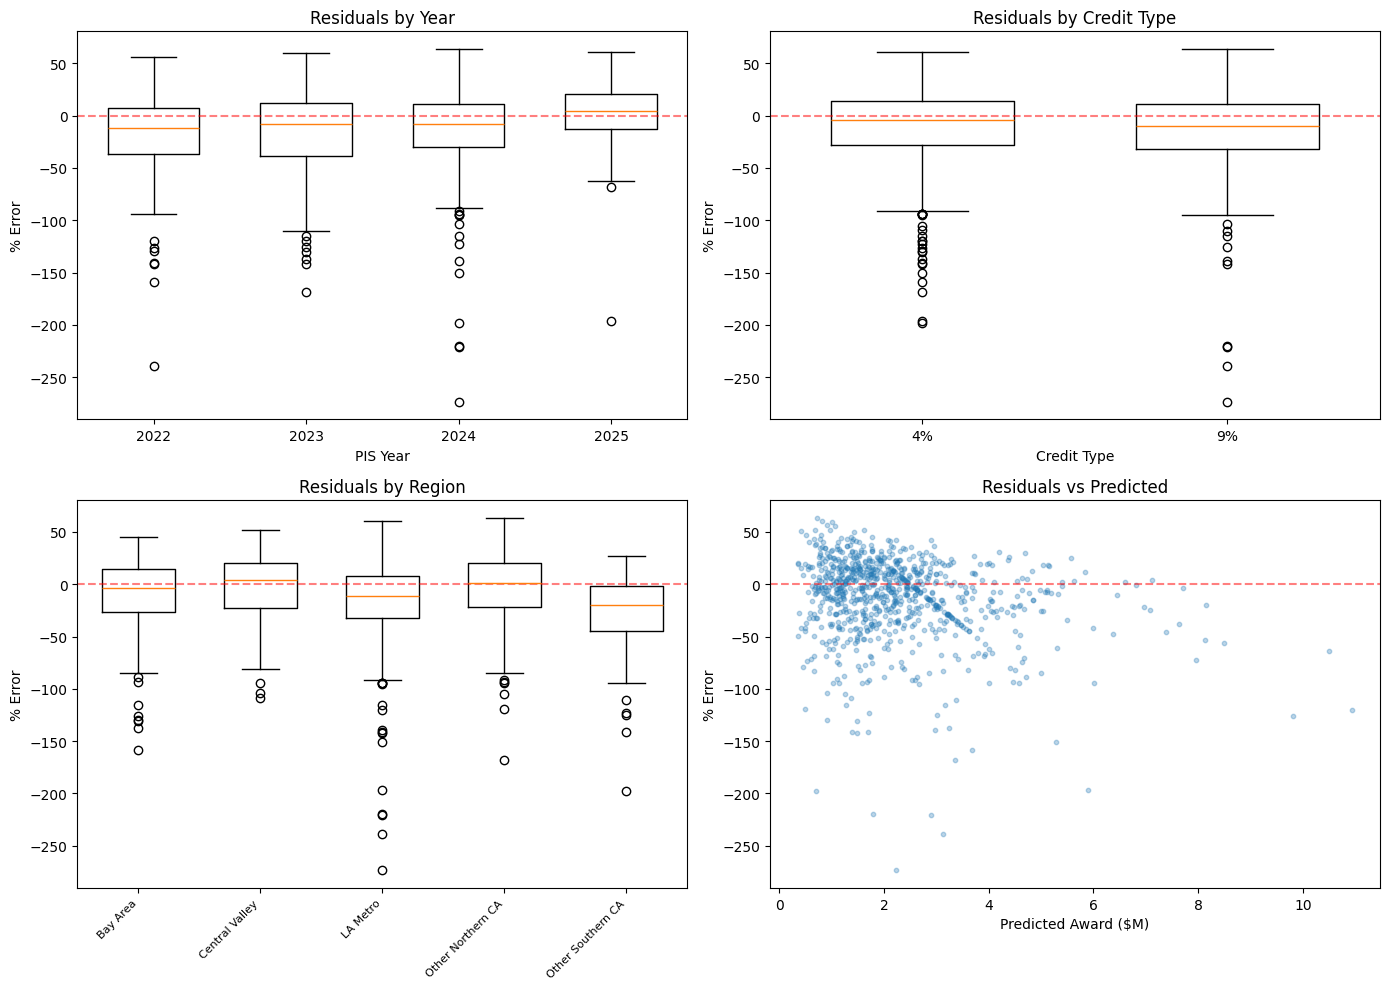

Median % error by credit type:
  4%: -4.1%
  9%: -9.6%

Median % error by region:
  Bay Area: -4.0%
  Central Valley: 3.8%
  LA Metro: -11.2%
  Other Northern CA: 1.7%
  Other Southern CA: -19.6%


In [16]:
# Use stacking as the best model for residual analysis
residuals = y_test_raw - stacking_preds
pct_errors = residuals / y_test_raw * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals by year
ax = axes[0, 0]
for year in sorted(df_test['pis_year'].unique()):
    mask = df_test['pis_year'].values == year
    ax.boxplot(pct_errors[mask], positions=[year], widths=0.6)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('PIS Year')
ax.set_ylabel('% Error')
ax.set_title('Residuals by Year')

# 2. Residuals by credit type
ax = axes[0, 1]
for i, ct in enumerate(sorted(df_test['credit_type'].unique())):
    mask = df_test['credit_type'].values == ct
    ax.boxplot(pct_errors[mask], positions=[i], widths=0.6, labels=[ct])
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Credit Type')
ax.set_ylabel('% Error')
ax.set_title('Residuals by Credit Type')

# 3. Residuals by region
ax = axes[1, 0]
regions = sorted(df_test['region'].unique())
for i, reg in enumerate(regions):
    mask = df_test['region'].values == reg
    ax.boxplot(pct_errors[mask], positions=[i], widths=0.6)
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('% Error')
ax.set_title('Residuals by Region')

# 4. Residuals vs predicted (heteroscedasticity check)
ax = axes[1, 1]
ax.scatter(stacking_preds / 1e6, pct_errors, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Predicted Award ($M)')
ax.set_ylabel('% Error')
ax.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

# Summary stats by subgroup
print('Median % error by credit type:')
for ct in sorted(df_test['credit_type'].unique()):
    mask = df_test['credit_type'].values == ct
    print(f'  {ct}: {np.median(pct_errors[mask]):.1f}%')

print('\nMedian % error by region:')
for reg in regions:
    mask = df_test['region'].values == reg
    print(f'  {reg}: {np.median(pct_errors[mask]):.1f}%')

## 13. SHAP Explainability

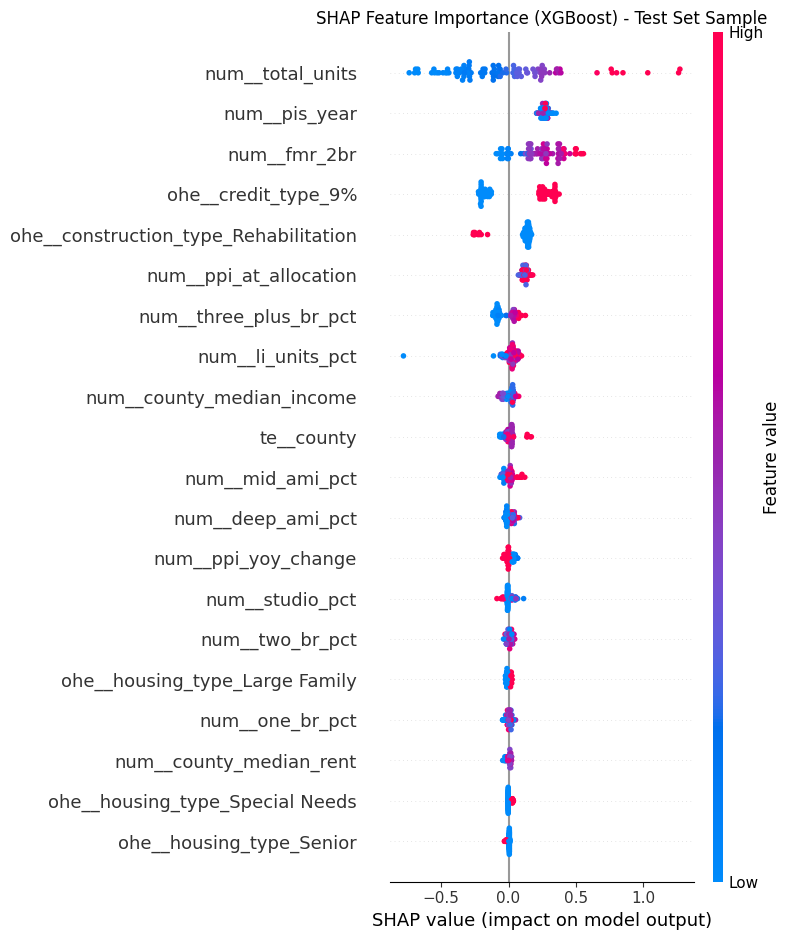

In [19]:


# SHAP for XGBoost (TreeExplainer)
# Use a sample of 100 test rows to keep memory usage reasonable
xgb_explainer = shap.TreeExplainer(xgb)
shap_sample = X_test[:100]
shap_values = xgb_explainer.shap_values(shap_sample)

# Global feature importance
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance (XGBoost) - Test Set Sample')
plt.tight_layout()
plt.show()

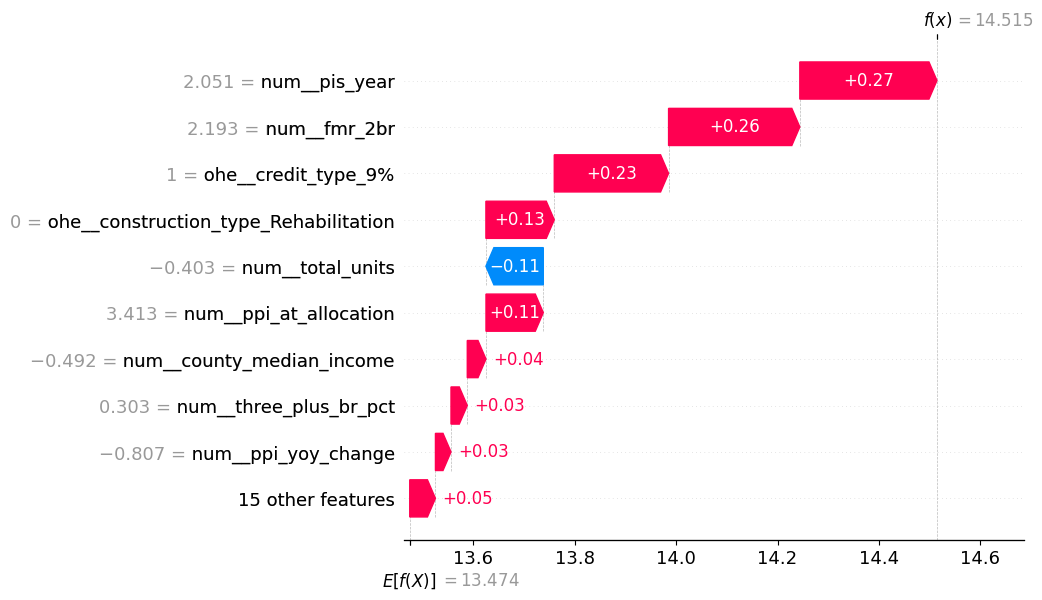

In [20]:
# Per-prediction waterfall for the first test observation
shap.initjs()
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=xgb_explainer.expected_value,
    data=X_test[0],
    feature_names=feature_names,
)
shap.waterfall_plot(explanation)

## 14. Actual vs Predicted Plot

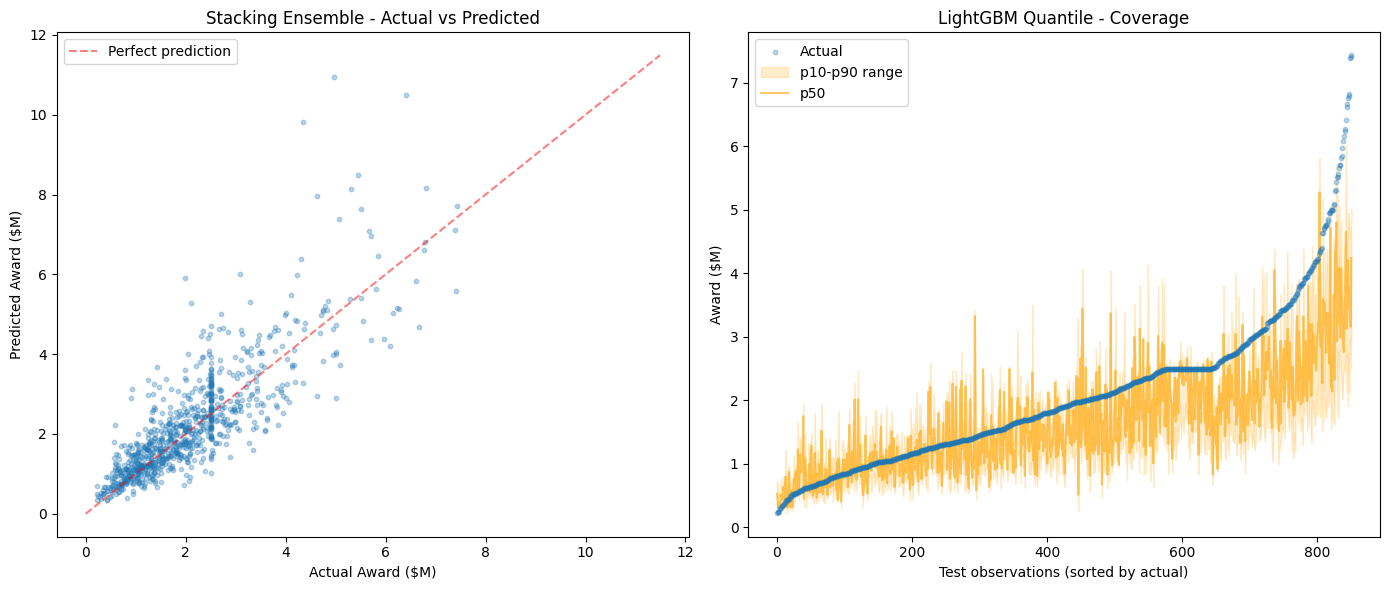

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacking: actual vs predicted
ax = axes[0]
ax.scatter(y_test_raw / 1e6, stacking_preds / 1e6, alpha=0.3, s=10)
lims = [0, max(y_test_raw.max(), stacking_preds.max()) / 1e6 * 1.05]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual Award ($M)')
ax.set_ylabel('Predicted Award ($M)')
ax.set_title('Stacking Ensemble - Actual vs Predicted')
ax.legend()

# LightGBM quantile: actual vs p50 with confidence bands
ax = axes[1]
sort_idx = np.argsort(y_test_raw)
ax.scatter(range(len(y_test_raw)), y_test_raw[sort_idx] / 1e6, alpha=0.3, s=10, label='Actual', zorder=3)
ax.fill_between(range(len(y_test_raw)), 
                p10_preds[sort_idx] / 1e6, p90_preds[sort_idx] / 1e6,
                alpha=0.2, color='orange', label='p10-p90 range')
ax.plot(range(len(y_test_raw)), p50_preds[sort_idx] / 1e6, 'orange', alpha=0.6, label='p50')
ax.set_xlabel('Test observations (sorted by actual)')
ax.set_ylabel('Award ($M)')
ax.set_title('LightGBM Quantile - Coverage')
ax.legend()

plt.tight_layout()
plt.show()

## 15. Market Comparables — KNN

In [22]:
# KNN on the full scoped dataset (train + test) for market comparables
X_all = np.vstack([X_train, X_test])
df_all = pd.concat([df_train, df_test], ignore_index=True)

knn = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn.fit(X_all)

# Demo: find 10 nearest neighbors for the first test project
distances, indices = knn.kneighbors(X_test[:1])

print(f'Query project: {df_test.iloc[0]["project_name"]} ({df_test.iloc[0]["county"]}, {df_test.iloc[0]["pis_year"]})')
print(f'Annual Federal Award: ${df_test.iloc[0]["annual_federal_award"]:,.0f}')
print(f'\nTop 10 comparable projects:')
comps = df_all.iloc[indices[0]][['project_name', 'county', 'pis_year', 'credit_type', 
                                  'housing_type', 'total_units', 'annual_federal_award']].copy()
comps['distance'] = distances[0]
comps

Query project: El Nuevo Amanecer Apartments (Los Angeles, 2024)
Annual Federal Award: $2,172,058

Top 10 comparable projects:


,project_name,county,pis_year,credit_type,housing_type,total_units,annual_federal_award,distance
3536,El Nuevo Amanecer Apartments,Los Angeles,2024,9%,Large Family,61.0000,"2,172,058.0000",0.0000
4127,Chapel Avenue Apartments,Los Angeles,2024,9%,Large Family,44.0000,"2,191,271.0000",0.0000
4102,Norwalk Veterans Housing,Los Angeles,2024,9%,Large Family,60.0000,"2,043,423.0000",0.0000
4105,Red Tail Crossing,Los Angeles,2024,9%,Large Family,102.0000,"2,500,000.0000",0.0000
4223,Lakeland Apartments,Los Angeles,2024,4%,Large Family,102.0000,"2,959,547.0000",0.0000
3813,Corazón del Valle,Los Angeles,2024,4%,Large Family,90.0000,"1,811,502.0000",0.0000
4111,Miramar Gold,Los Angeles,2024,9%,Special Needs,94.0000,"1,981,106.0000",0.0000
3835,Juniper Grove Apartments,Los Angeles,2024,9%,Special Needs,101.0000,"2,054,336.0000",0.0000
3982,Washington Arts Collective,Los Angeles,2024,4%,Special Needs,56.0000,"1,516,340.0000",0.0000
3839,Los Lirios Apartments,Los Angeles,2024,9%,Large Family,64.0000,"2,500,000.0000",0.0000


## 16. Project Archetypes — KMeans

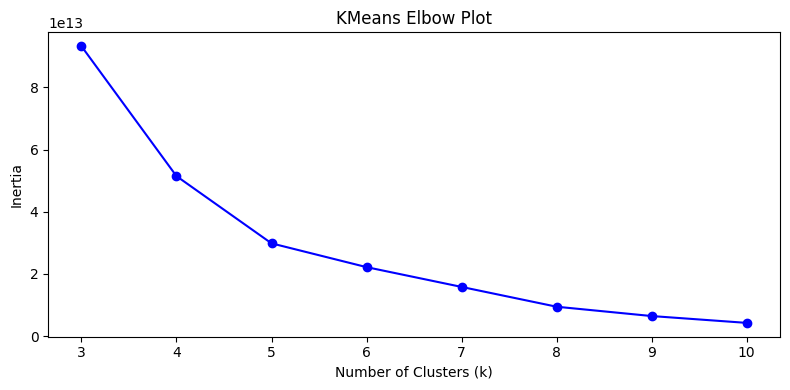

In [23]:
# Determine optimal k via inertia elbow
inertias = []
K_range = range(3, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_all)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('KMeans Elbow Plot')
plt.tight_layout()
plt.show()

In [24]:
# Fit final KMeans with k=6 (adjust based on elbow plot)
N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_all['cluster'] = kmeans.fit_predict(X_all)

# Cluster profiles
cluster_profile = df_all.groupby('cluster').agg(
    count=('annual_federal_award', 'size'),
    median_award=('annual_federal_award', 'median'),
    median_units=('total_units', 'median'),
    top_credit_type=('credit_type', lambda x: x.mode().iloc[0]),
    top_housing_type=('housing_type', lambda x: x.mode().iloc[0]),
    top_region=('region', lambda x: x.mode().iloc[0]),
    median_year=('pis_year', 'median'),
).reset_index()

print('Cluster Profiles (Project Archetypes):')
cluster_profile

Cluster Profiles (Project Archetypes):


,cluster,count,median_award,median_units,top_credit_type,top_housing_type,top_region,median_year
0,0,1011,"1,075,468.0000",82.0000,4%,Large Family,Bay Area,"2,015.0000"
1,1,1612,"877,675.5000",70.0000,4%,Large Family,LA Metro,"2,014.0000"
2,2,205,"1,654,658.0000",100.0000,4%,Non-Targeted,Bay Area,"2,016.0000"
3,3,330,"679,924.5000",54.5000,9%,Large Family,Other Northern CA,"2,014.0000"
4,4,962,"701,005.5000",68.0000,9%,Large Family,Other Northern CA,"2,014.0000"
5,5,267,"782,855.0000",66.0000,4%,Large Family,Bay Area,"2,013.0000"


## 17. Save All Models

In [25]:
# Save the best credit prediction model (Stacking)
joblib.dump(stacking, os.path.join(MODEL_DIR, 'credit_model.pkl'))
print('Saved: models/credit_model.pkl (StackingRegressor)')

# Save individual base models for reference
joblib.dump(ridge, os.path.join(MODEL_DIR, 'ridge_model.pkl'))
joblib.dump(rf, os.path.join(MODEL_DIR, 'rf_model.pkl'))
joblib.dump(xgb, os.path.join(MODEL_DIR, 'xgb_model.pkl'))
print('Saved: models/ridge_model.pkl, rf_model.pkl, xgb_model.pkl')

# Save quantile models
joblib.dump(quantile_models, os.path.join(MODEL_DIR, 'credit_quantile.pkl'))
print('Saved: models/credit_quantile.pkl (LightGBM p10/p50/p90)')

# Save KNN and KMeans
joblib.dump(knn, os.path.join(MODEL_DIR, 'knn_model.pkl'))
joblib.dump(kmeans, os.path.join(MODEL_DIR, 'kmeans_model.pkl'))
print('Saved: models/knn_model.pkl, kmeans_model.pkl')

# Save the SHAP explainer
joblib.dump(xgb_explainer, os.path.join(MODEL_DIR, 'shap_explainer.pkl'))
print('Saved: models/shap_explainer.pkl')

# Save the full scoped dataset (for comparables lookup in the app)
df_all.to_parquet(os.path.join(MODEL_DIR, 'df_all_scoped.parquet'), index=False)
print('Saved: models/df_all_scoped.parquet')

# Save model comparison results
results_df.to_csv(os.path.join(MODEL_DIR, 'model_comparison.csv'), index=False)
print('Saved: models/model_comparison.csv')

Saved: models/credit_model.pkl (StackingRegressor)
Saved: models/ridge_model.pkl, rf_model.pkl, xgb_model.pkl
Saved: models/credit_quantile.pkl (LightGBM p10/p50/p90)
Saved: models/knn_model.pkl, kmeans_model.pkl
Saved: models/shap_explainer.pkl
Saved: models/df_all_scoped.parquet
Saved: models/model_comparison.csv


## 18. Summary

In [26]:
print('=' * 60)
print('NOTEBOOK 04 - MODELING SUMMARY')
print('=' * 60)
print(f'Training set:  {X_train.shape[0]:,} rows (2000-2021)')
print(f'Test set:      {X_test.shape[0]:,} rows (2022-2025)')
print(f'Features:      {X_train.shape[1]} (after encoding)')
print(f'Target:        log1p(annual_federal_award)')
print()
print('Models trained and saved:')
print('  1. Ridge Regression (baseline)')
print('  2. Random Forest (tuned via RandomizedSearchCV + TimeSeriesCV)')
print('  3. XGBoost (tuned via RandomizedSearchCV + TimeSeriesCV)')
print('  4. Stacking Ensemble (Ridge+RF+XGB -> Ridge meta) <- best model')
print('  5. LightGBM Quantile (p10/p50/p90) <- confidence ranges')
print('  6. KNN (k=10, cosine) <- market comparables')
print(f'  7. KMeans (k={N_CLUSTERS}) <- project archetypes')
print()
print(f'p10-p90 coverage: {coverage:.1f}%')
print()
print('Saved artifacts in models/:')
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f} ({size:.0f} KB)')
print('=' * 60)
print('\nNext: Build streamlit_app.py')

NOTEBOOK 04 - MODELING SUMMARY
Training set:  3,536 rows (2000-2021)
Test set:      851 rows (2022-2025)
Features:      24 (after encoding)
Target:        log1p(annual_federal_award)

Models trained and saved:
  1. Ridge Regression (baseline)
  2. Random Forest (tuned via RandomizedSearchCV + TimeSeriesCV)
  3. XGBoost (tuned via RandomizedSearchCV + TimeSeriesCV)
  4. Stacking Ensemble (Ridge+RF+XGB -> Ridge meta) <- best model
  5. LightGBM Quantile (p10/p50/p90) <- confidence ranges
  6. KNN (k=10, cosine) <- market comparables
  7. KMeans (k=6) <- project archetypes

p10-p90 coverage: 44.4%

Saved artifacts in models/:
  X_test.npy (160 KB)
  X_train.npy (663 KB)
  credit_model.pkl (153416 KB)
  credit_quantile.pkl (2438 KB)
  df_all_scoped.parquet (459 KB)
  feature_config.pkl (1 KB)
  feature_pipeline.pkl (14 KB)
  kmeans_model.pkl (19 KB)
  knn_model.pkl (823 KB)
  model_comparison.csv (1 KB)
  rf_model.pkl (76479 KB)
  ridge_model.pkl (1 KB)
  shap_explainer.pkl (551 KB)
  test